<a href="https://colab.research.google.com/github/aseel-analytics/System_Usage_Analysis/blob/main/system_Usage_Analysis_Aseel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving System_Usage_Example (1).csv to System_Usage_Example (1).csv


In [2]:
import pandas as pd

# قراءة الملف اللي رفعتيه
df = pd.read_csv(list(uploaded.keys())[0])

# عرض أول 5 صفوف
df.head()


,UserID,Activity,Date,Time
0,101,Login,2026-01-01,08:00
1,102,Upload,2026-01-01,09:15
2,103,Download,2026-01-01,10:30
3,101,Error,2026-01-02,08:45
4,102,Login,2026-01-02,09:00


In [3]:
# عدد المستخدمين الفريدين
unique_users = df['UserID'].nunique()
print("عدد المستخدمين الفريدين:", unique_users)

# عدد الدخول لكل مستخدم
entries_per_user = df['UserID'].value_counts()
print("\nعدد الدخول لكل مستخدم:")
print(entries_per_user)


عدد المستخدمين الفريدين: 5

عدد الدخول لكل مستخدم:
UserID
101    3
102    2
103    2
104    2
105    1
Name: count, dtype: int64


In [5]:
# أكثر نوع نشاط مستخدم
activity_counts = df['Activity'].value_counts()
print("عدد كل نوع نشاط:")
print(activity_counts)

# عرض فقط الأنشطة اللي فيها 'Error'
errors = df[df['Activity'] == 'Error']
print("\nسجلات الأخطاء:")
print(errors)



عدد كل نوع نشاط:
Activity
Login       4
Upload      2
Download    2
Error       2
Name: count, dtype: int64

سجلات الأخطاء:
   UserID Activity        Date   Time
3     101    Error  2026-01-02  08:45
8     103    Error  2026-01-03  10:00


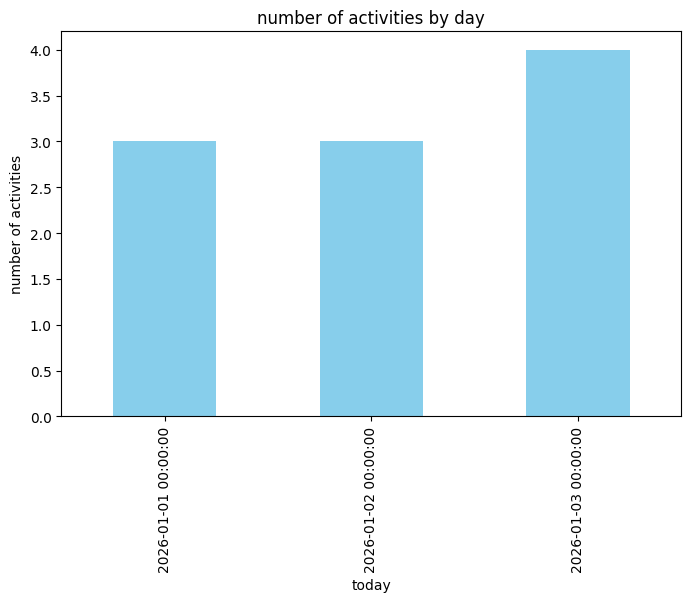

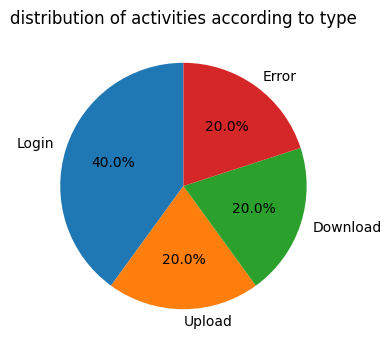

In [9]:
import matplotlib.pyplot as plt

# تحويل العمود Date إلى نوع تاريخي
df['Date'] = pd.to_datetime(df['Date'])

# نشاطات حسب اليوم
activity_per_day = df.groupby('Date')['Activity'].count()

# رسم بياني للنشاطات حسب اليوم
plt.figure(figsize=(8,5))
activity_per_day.plot(kind='bar', color='skyblue')
plt.title('number of activities by day')
plt.xlabel('today')
plt.ylabel('number of activities')
plt.show()

# نشاطات حسب النوع (Visualization)
plt.figure(figsize=(6,4))
activity_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('distribution of activities according to type')
plt.ylabel('')
plt.show()

